In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

**Упражнение 1**

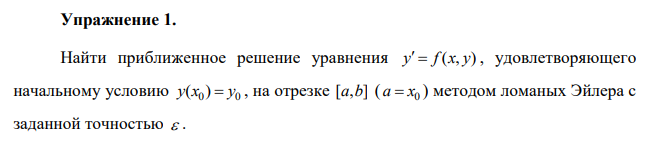

$y`=x*y$

$\frac{\mathrel{\clap{\;|}{d}}y}{\mathrel{\clap{\;|}{d}}x} = x*y$  $| *\frac{\mathrel{\clap{\;|}{d}}x}{y}$

$\frac{\mathrel{\clap{\;|}{d}}y}{y} = x*dx$

$\ln{y}=\frac{x^2}{2}+C$

$\mathrel{\clap{\;|}{e}}^{\ln{y}}=y=\mathrel{\clap{\;|}{e}}^{\frac{x^2}{2}}*\mathrel{\clap{\;|}{e}}^C$

$y(0)=1$

$1=\mathrel{\clap{\;|}{e}}^0*\mathrel{\clap{\;|}{e}}^C=1*\mathrel{\clap{\;|}{e}}^C=\mathrel{\clap{\;|}{e}}^C$

$y=\mathrel{\clap{\;|}{e}}^{\frac{x^2}{2}}$

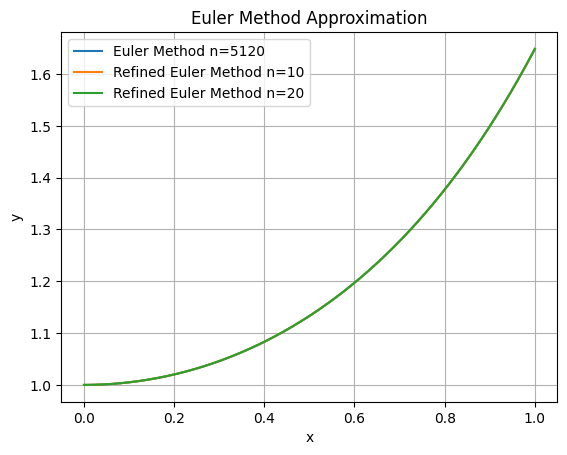

Maximum error: 0.00021464231497780872


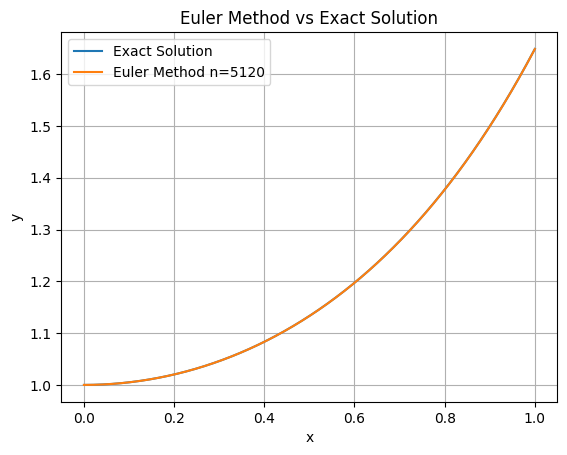

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
def EuilerMethod(f, x, y, x0, y0, a, b, n0, epsilon):
    func = sp.lambdify((x, y), f, 'numpy')
    n = n0
    h = (b - a) / n
    while True:
        xs = np.zeros(n + 1)
        ys = np.zeros(n + 1)
        xs[0] = x0
        ys[0] = y0
        for i in range(n):
            xs[i + 1] = xs[i] + h
            ys[i + 1] = ys[i] + h * func(xs[i], ys[i])
        if n > n0:
            errors = np.array([])
            for i in range(1, n, 2):
                errors = np.append(errors, np.abs(ys[i] - y_prev[i // 2]))
            error = np.max(errors)
            if error < epsilon:
                break
        y_prev = ys.copy()
        n *= 2
        h /= 2
    
    plt.plot(xs, ys, label=f'Euler Method n={n}')
    xs0 = np.linspace(a, b, n)
    xs1 = np.linspace(a, b, 2*n)
    ys0 = np.zeros_like(xs0)
    ys1 = np.zeros_like(xs1)
    ys0[0] = y0
    ys1[0] = y0
    for i in range(1, len(xs0)):
        ys0[i] = ys0[i-1] + h * func(xs0[i-1], ys0[i-1])
    for i in range(1, len(xs1)):
        ys1[i] = ys1[i-1] + h/2 * func(xs1[i-1], ys1[i-1])
    plt.plot(xs0, ys0, label=f'Refined Euler Method n={n0}')
    plt.plot(xs1, ys1, label=f'Refined Euler Method n={2*n0}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Euler Method Approximation')
    plt.legend()
    plt.grid()
    plt.show()
    return xs, ys, n



x, y = sp.symbols('x y')
f = x * y 
xs, ys, n = EuilerMethod(f, x, y, 0, 1, 0, 1, 10, 0.001)
xt = np.linspace(0, 1, 1000)
yt = np.exp(0.5 * xt**2)
error = 0
for i in range(len(xs)):
    error = max(error, abs(ys[i] - np.exp(0.5 * xs[i]**2)))
print(f'Maximum error: {error}')
plt.plot(xt, yt, label='Exact Solution')
plt.plot(xs, ys, label=f'Euler Method n={n}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Euler Method vs Exact Solution')
plt.legend()
plt.grid()
plt.show()

**Упражнение 2(Финал)**

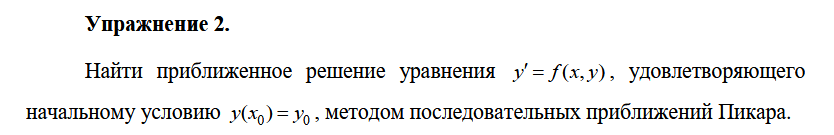

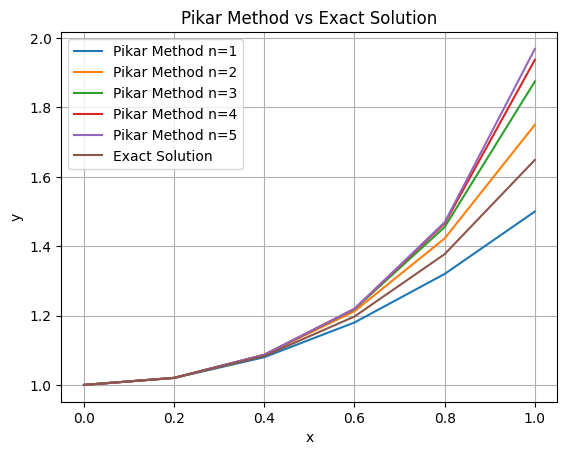

Minimum error for Pikar Method n=5: 0.101278729299872


In [9]:
def PikarMethod(f, x, y, x0, y0, n0):
    funcs = [y0]
    t = sp.symbols('t')
    xs = np.linspace(x0, x0 + 1, n0 + 1)
    for i in range(1, n0 + 1):
        func = f.subs(x, t).subs(y, funcs[i - 1][0] if isinstance(funcs[i - 1], list) else funcs[i - 1])
        funci = y0 + sp.integrate(func, (t, x0, x))
        ys = [funci.subs(x, xi) for xi in xs]
        funcs.append([funci, ys])
    return funcs

x, y = sp.symbols('x y')
f = x * y
res = PikarMethod(f, x, y, 0, 1, 5)
xs = np.linspace(0, 1, 6)
ys = np.exp(xs**2 / 2)
for i in range(1, 6):
    plt.plot(xs, res[i][1], label=f'Pikar Method n={i}')
plt.plot(xs, ys, label='Exact Solution')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Pikar Method vs Exact Solution')
plt.grid()
plt.show()
error = float('inf')
for j in range(1, 6):
    error = min(error, abs(ys[5] - res[j][1][5]))
print(f'Minimum error for Pikar Method n=5: {error}')